In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np 


In [21]:
data = pd.read_csv(r"C:/Users/vedan/OneDrive/Desktop/End to End projects/SMART_Banking_System/data/loan_approval.csv")

In [23]:
data.head()

,name,city,income,credit_score,loan_amount,years_employed,points,loan_approved
0,Allison Hill,East Jill,113810,389,39698,27,50.0,False
1,Brandon Hall,New Jamesside,44592,729,15446,28,55.0,False
2,Rhonda Smith,Lake Roberto,33278,584,11189,13,45.0,False
3,Gabrielle Davis,West Melanieview,127196,344,48823,29,50.0,False
4,Valerie Gray,Mariastad,66048,496,47174,4,25.0,False


In [25]:
data.count()

name              2000
city              2000
income            2000
credit_score      2000
loan_amount       2000
years_employed    2000
points            2000
loan_approved     2000
dtype: int64

In [27]:
data['loan_approved'].value_counts(normalize = True)*100 #//normalize = True Retruns proportion 

loan_approved
False    56.05
True     43.95
Name: proportion, dtype: float64

In [29]:
data.isnull().sum()

name              0
city              0
income            0
credit_score      0
loan_amount       0
years_employed    0
points            0
loan_approved     0
dtype: int64

In [31]:
data.shape

(2000, 8)

In [33]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   name            2000 non-null   object 
 1   city            2000 non-null   object 
 2   income          2000 non-null   int64  
 3   credit_score    2000 non-null   int64  
 4   loan_amount     2000 non-null   int64  
 5   years_employed  2000 non-null   int64  
 6   points          2000 non-null   float64
 7   loan_approved   2000 non-null   bool   
dtypes: bool(1), float64(1), int64(4), object(2)
memory usage: 111.5+ KB


In [35]:
data.describe()

,income,credit_score,loan_amount,years_employed,points
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,90585.977000,573.946000,25308.503000,20.441000,56.680000
std,34487.874907,160.564945,14207.320147,11.777813,18.638033
min,30053.000000,300.000000,1022.000000,0.000000,10.000000
25%,61296.250000,433.000000,12748.750000,10.000000,45.000000
50%,90387.500000,576.000000,25661.500000,21.000000,55.000000
75%,120099.750000,715.000000,37380.500000,31.000000,70.000000
max,149964.000000,850.000000,49999.000000,40.000000,100.000000


In [37]:
data.duplicated().sum()

0

In [39]:
data=data.drop(['name'],axis = 1)

In [41]:
data = data.drop(['city'],axis = 1)

In [43]:
data['years_employed'].skew()

-0.027956568967589055

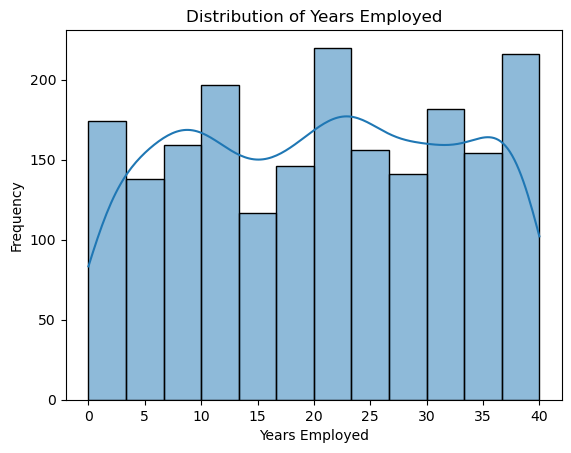

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(data['years_employed'], kde=True)

plt.title("Distribution of Years Employed")
plt.xlabel("Years Employed")
plt.ylabel("Frequency")

plt.show()

<Axes: ylabel='income'>

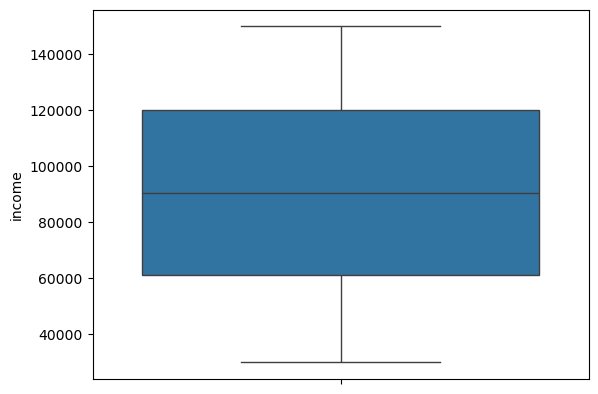

In [46]:
sns.boxplot(data['income'])

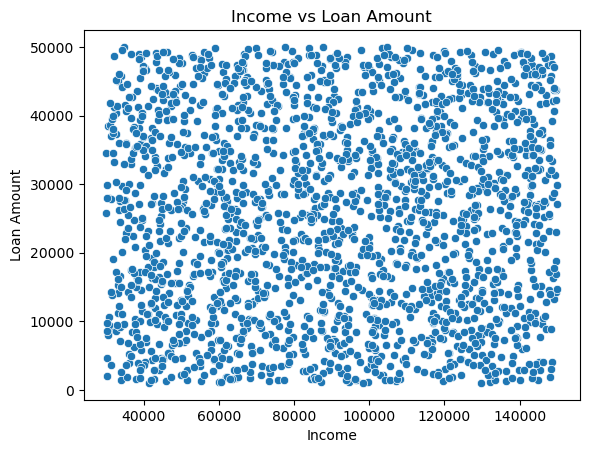

In [47]:
sns.scatterplot(x = 'income',y = 'loan_amount',data = data)
plt.title("Income vs Loan Amount")
plt.xlabel("Income")
plt.ylabel("Loan Amount")

plt.show()

In [48]:
data[['income', 'loan_amount']].corr() #very week correaleation

,income,loan_amount
income,1.000000,0.037612
loan_amount,0.037612,1.000000


In [50]:
data.corr()

,income,credit_score,loan_amount,years_employed,points,loan_approved
income,1.000000,-0.027113,0.037612,-0.014441,0.451142,0.238066
credit_score,-0.027113,1.000000,-0.008076,0.023598,0.740899,0.715788
loan_amount,0.037612,-0.008076,1.000000,0.013015,-0.223039,-0.157859
years_employed,-0.014441,0.023598,0.013015,1.000000,0.156441,0.104408
points,0.451142,0.740899,-0.223039,0.156441,1.000000,0.821415
loan_approved,0.238066,0.715788,-0.157859,0.104408,0.821415,1.000000


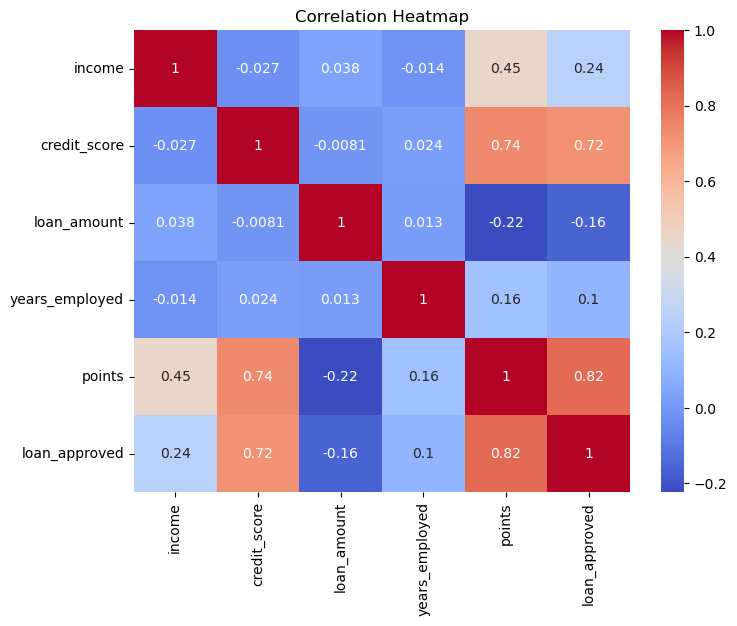

In [55]:
plt.figure(figsize=(8,6))

sns.heatmap(data.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

In [57]:
#sns.barplot(x = 'loan_approved',y='loan_amount')

Text(0.5, 1.0, 'loan_approval vs credit score')

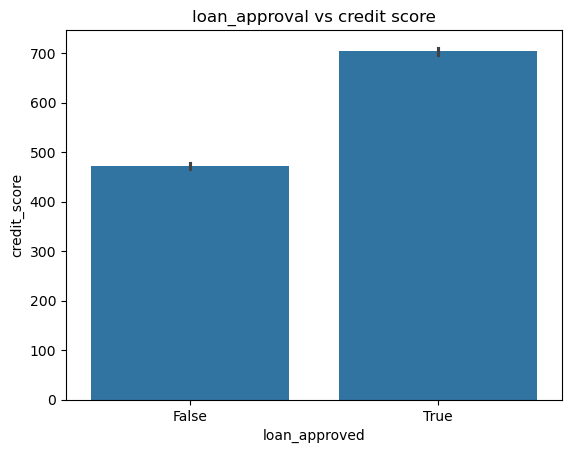

In [59]:
sns.barplot(x = 'loan_approved',y='credit_score',data = data)
plt.title("loan_approval vs credit score")

In [61]:
data['loan_income_ratio'] = data['loan_amount']/data['income']

In [63]:
data

,income,credit_score,loan_amount,years_employed,points,loan_approved,loan_income_ratio
0,113810,389,39698,27,50.0,False,0.348809
1,44592,729,15446,28,55.0,False,0.346385
2,33278,584,11189,13,45.0,False,0.336228
3,127196,344,48823,29,50.0,False,0.383841
4,66048,496,47174,4,25.0,False,0.714238
...,...,...,...,...,...,...,...
1995,92163,770,12251,13,85.0,True,0.132928
1996,38799,635,48259,17,40.0,False,1.243821
1997,41957,763,16752,5,60.0,True,0.399266
1998,139022,360,24031,35,55.0,False,0.172858


Text(0.5, 1.0, 'loan_approval vs loan income ratio ')

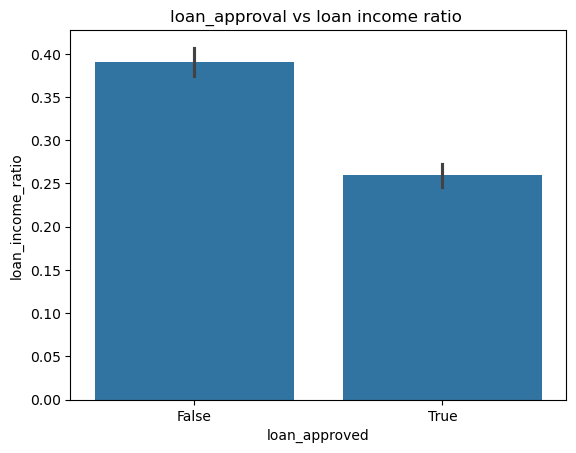

In [65]:
sns.barplot(x = 'loan_approved',y='loan_income_ratio',data = data)
plt.title("loan_approval vs loan income ratio ") #from here we can see the low the income ratio the higher chance of loan approval

In [67]:



data[['loan_income_ratio', 'loan_approved']].corr()# negative corr means higher chance of false 

,loan_income_ratio,loan_approved
loan_income_ratio,1.000000,-0.249378
loan_approved,-0.249378,1.000000


In [70]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   income             2000 non-null   int64  
 1   credit_score       2000 non-null   int64  
 2   loan_amount        2000 non-null   int64  
 3   years_employed     2000 non-null   int64  
 4   points             2000 non-null   float64
 5   loan_approved      2000 non-null   bool   
 6   loan_income_ratio  2000 non-null   float64
dtypes: bool(1), float64(2), int64(4)
memory usage: 95.8 KB


In [72]:
data['loan_approved'] = data['loan_approved'].astype(int)


In [74]:
data['loan_approved'].value_counts(normalize = True)*100

loan_approved
0    56.05
1    43.95
Name: proportion, dtype: float64

In [77]:
X = data.drop(['loan_approved', 'points'], axis=1)
y = data['loan_approved']

In [79]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state= 18)

In [81]:
X_train

,income,credit_score,loan_amount,years_employed,loan_income_ratio
1835,37936,376,8418,30,0.221900
91,89429,424,2891,40,0.032327
383,51579,404,1481,32,0.028713
1881,134662,498,46916,23,0.348398
749,118184,506,33568,40,0.284032
...,...,...,...,...,...
1726,68684,460,16349,2,0.238032
837,61358,831,26872,16,0.437954
1144,127370,844,7621,17,0.059834
275,118039,849,39916,40,0.338159


In [83]:
X_test

,income,credit_score,loan_amount,years_employed,loan_income_ratio
452,64814,355,36969,29,0.570386
361,142898,601,44386,40,0.310613
830,113579,752,46709,22,0.411247
1989,70963,489,5890,6,0.083001
161,77447,401,47838,21,0.617687
...,...,...,...,...,...
398,124163,836,23140,27,0.186368
570,62706,461,21807,4,0.347766
1500,149725,665,14304,9,0.095535
1694,70492,402,24758,7,0.351217


In [85]:
y_test

452     0
361     1
830     1
1989    0
161     0
       ..
398     1
570     0
1500    1
1694    0
457     1
Name: loan_approved, Length: 400, dtype: int32

In [87]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [104]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_Scaled = scaler.fit_transform(X_train)

X_test_Scaled = scaler.transform(X_test)

In [107]:
"""import matplotlib.pyplot as plt

from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Select only 2 features for visualization
X_plot = X[["credit_score", "loan_income_ratio"]]

# Scale features
scaler = StandardScaler()
X_plot_scaled = scaler.fit_transform(X_plot)

# Logistic Regression model
clf = LogisticRegression()


def fit_and_plot_model(X_plot, y, clf, ax):
    clf.fit(X_plot, y)

    disp = DecisionBoundaryDisplay.from_estimator(
        clf,
        X_plot,
        response_method="predict",
        alpha=0.5,
        ax=ax,
    )

    disp.ax_.scatter(
        X_plot[:, 0] if not hasattr(X_plot, "columns") else X_plot["credit_score"],
        X_plot[:, 1] if not hasattr(X_plot, "columns") else X_plot["loan_income_ratio"],
        c=y,
        s=20,
        edgecolor="k",
    )

    return disp.ax_


fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 6))

# Without scaling
fit_and_plot_model(X_plot, y, clf, ax1)
ax1.set_title("Logistic Regression without scaling")
ax1.set_xlabel("credit_score")
ax1.set_ylabel("loan_income_ratio")

# With scaling
fit_and_plot_model(X_plot_scaled, y, clf, ax2)
ax2.set_title("Logistic Regression with scaling")
ax2.set_xlabel("scaled credit_score")
ax2.set_ylabel("scaled loan_income_ratio")

plt.show()"""

'import matplotlib.pyplot as plt\n\nfrom sklearn.inspection import DecisionBoundaryDisplay\nfrom sklearn.linear_model import LogisticRegression\nfrom sklearn.preprocessing import StandardScaler\n\n# Select only 2 features for visualization\nX_plot = X[["credit_score", "loan_income_ratio"]]\n\n# Scale features\nscaler = StandardScaler()\nX_plot_scaled = scaler.fit_transform(X_plot)\n\n# Logistic Regression model\nclf = LogisticRegression()\n\n\ndef fit_and_plot_model(X_plot, y, clf, ax):\n    clf.fit(X_plot, y)\n\n    disp = DecisionBoundaryDisplay.from_estimator(\n        clf,\n        X_plot,\n        response_method="predict",\n        alpha=0.5,\n        ax=ax,\n    )\n\n    disp.ax_.scatter(\n        X_plot[:, 0] if not hasattr(X_plot, "columns") else X_plot["credit_score"],\n        X_plot[:, 1] if not hasattr(X_plot, "columns") else X_plot["loan_income_ratio"],\n        c=y,\n        s=20,\n        edgecolor="k",\n    )\n\n    return disp.ax_\n\n\nfig, (ax1, ax2) = plt.subplots(n

In [115]:
scaled_X_train = pd.DataFrame(X_train_Scaled,columns = X_train.columns)

In [117]:
scaled_X_train

,income,credit_score,loan_amount,years_employed,loan_income_ratio
0,-1.534853,-1.234562,-1.206442,0.829242,-0.434478
1,-0.039681,-0.934009,-1.596823,1.681275,-1.167944
2,-1.138709,-1.059240,-1.696414,0.999648,-1.181927
3,1.273724,-0.470658,1.512739,0.232818,0.054949
4,0.795262,-0.420566,0.569947,1.681275,-0.194088
...,...,...,...,...,...
1595,-0.642041,-0.708595,-0.646261,-1.556452,-0.372062
1596,-0.854762,1.614424,0.096997,-0.363605,0.401446
1597,1.061990,1.695823,-1.262735,-0.278402,-1.061521
1598,0.791051,1.727131,1.018317,1.681275,0.015335


In [119]:
scaled_X_test = pd.DataFrame(X_test_Scaled,columns = X_test.columns)

In [123]:
scaled_X_test

,income,credit_score,loan_amount,years_employed,loan_income_ratio
0,-0.754412,-1.366053,0.810165,0.744038,0.913831
1,1.512868,0.174277,1.334041,1.681275,-0.091243
2,0.661549,1.119765,1.498118,0.147615,0.298113
3,-0.575867,-0.527011,-1.384999,-1.215639,-0.971885
4,-0.387595,-1.078024,1.577862,0.062411,1.096840
...,...,...,...,...,...
395,0.968871,1.645731,-0.166601,0.573632,-0.571954
396,-0.815621,-0.702334,-0.260753,-1.386045,0.052502
397,1.711100,0.575014,-0.790703,-0.960029,-0.923390
398,-0.589543,-1.071763,-0.052319,-1.130435,0.065856


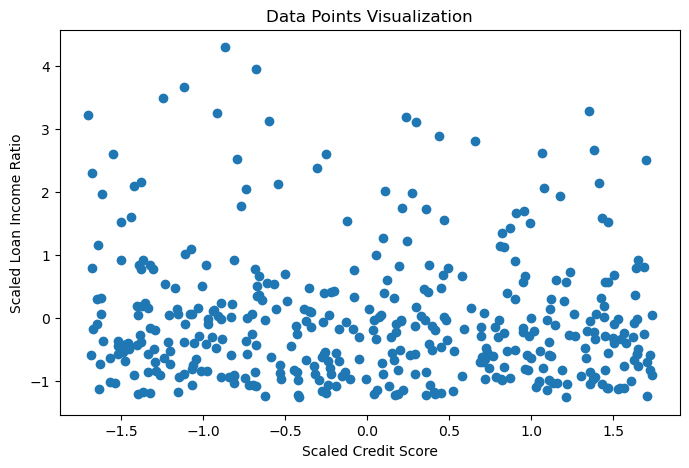

In [127]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(
   scaled_X_test['credit_score'],
   scaled_X_test['loan_income_ratio']
)

plt.xlabel("Scaled Credit Score")
plt.ylabel("Scaled Loan Income Ratio")
plt.title("Data Points Visualization")

plt.show()

In [129]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [133]:
lr = LogisticRegression()
dt = DecisionTreeClassifier()
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    min_samples_split=10,
    random_state=42
)

In [135]:
lr.fit(X_train_Scaled,y_train)
dt.fit(X_train_Scaled,y_train)
rf.fit(X_train_Scaled,y_train)


RandomForestClassifier(max_depth=5, min_samples_split=10, random_state=42)

In [137]:
y_pred1 = lr.predict(X_test_Scaled)
y_pred2 = dt.predict(X_test_Scaled)
y_pred3 = rf.predict(X_test_Scaled)

In [139]:
from sklearn.metrics import accuracy_score
accuracy1 = accuracy_score(y_pred1,y_test)
accuracy2 = accuracy_score(y_pred2,y_test)
accuracy3 = accuracy_score(y_pred3,y_test)


In [141]:
print(accuracy3)

0.9875


In [143]:
X_test_Scaled

array([[-0.75441228, -1.36605336,  0.81016525,  0.74403822,  0.91383055],
       [ 1.51286801,  0.1742773 ,  1.33404088,  1.68127502, -0.09124301],
       [ 0.66154903,  1.11976482,  1.49811842,  0.1476148 ,  0.2981133 ],
       ...,
       [ 1.71109969,  0.57501373, -0.7907032 , -0.9600287 , -0.92339008],
       [-0.58954345, -1.07176254, -0.05231896, -1.13043539,  0.06585578],
       [-0.62354511,  0.08661621, -1.08234167,  1.17005495, -0.72511776]])

In [147]:
'''from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)'''

'from sklearn.metrics import confusion_matrix\n\ncm = confusion_matrix(y_test, y_pred)\n\nprint(cm)'

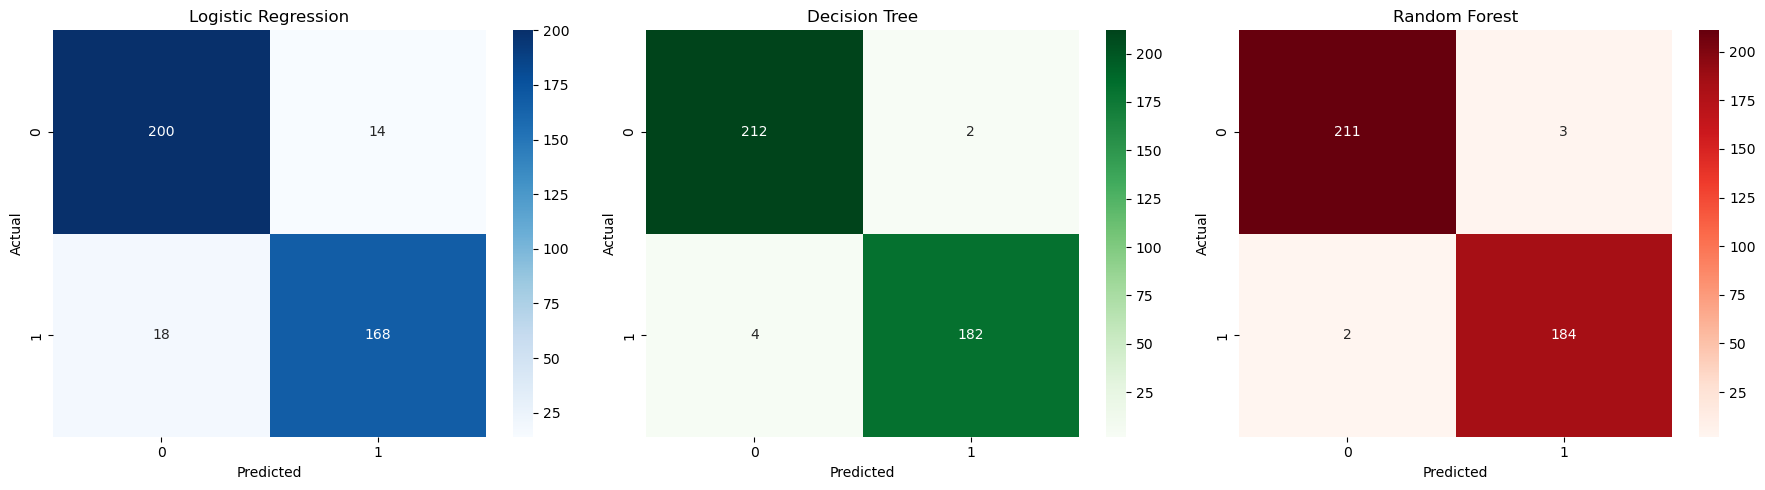

In [149]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Confusion matrices
cm1 = confusion_matrix(y_test, y_pred1)
cm2 = confusion_matrix(y_test, y_pred2)
cm3 = confusion_matrix(y_test, y_pred3)

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Logistic Regression
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title("Logistic Regression")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# Decision Tree
sns.heatmap(cm2, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title("Decision Tree")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

# Random Forest
sns.heatmap(cm3, annot=True, fmt='d', cmap='Reds', ax=axes[2])
axes[2].set_title("Random Forest")
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("Actual")

plt.tight_layout()
plt.show()

In [151]:
rf.score(X_train_Scaled, y_train)

0.984375

In [153]:
rf.score(X_test_Scaled, y_test)

0.9875

In [155]:
import pandas as pd

new_data = pd.DataFrame([
    [80000, 750, 20000, 10,  0.25],
    [40000, 500, 45000, 2,  1.12],
    [120000, 800, 15000, 15, 0.12]
], columns=[
    'income',
    'credit_score',
    'loan_amount',
    'years_employed',
    
    'loan_income_ratio'
])


In [157]:
new_data_scaled = scaler.transform(new_data)

In [159]:
predictions = rf.predict(new_data_scaled)

print(predictions)

[1 0 1]


In [161]:
probabilities = rf.predict_proba(new_data_scaled)

print(probabilities)

[[0.06005934 0.93994066]
 [0.9937969  0.0062031 ]
 [0.0381296  0.9618704 ]]


In [163]:
best_model = rf

In [165]:
best_model

RandomForestClassifier(max_depth=5, min_samples_split=10, random_state=42)

In [167]:
import pickle
import os
os.makedirs('C:/Users/vedan/OneDrive/Desktop/End to End projects/SMART_Banking_System/models',exist_ok=True)

In [169]:
pickle.dump(rf,open('C:/Users/vedan/OneDrive/Desktop/End to End projects/SMART_Banking_System/models/loan_approval_model.pkl','wb'))
print("saved Successfully")

saved Successfully
